# Clase 6: Evolución Estelar


## Objetivos
1. El Diagrama HR: El Espacio de Fase de la Evolución Estelar.
2. El Rol de la Metalicidad ($Z$) y la Opacidad.
3. Cronometría Estelar: El Main Sequence Turn-Off (MSTO).


## 1. El Diagrama HR: El Espacio de Fase de la Evolución Estelar

El Diagrama HR es el análogo astronómico de la tabla periódica. Nos permite clasificar el estado termodinámico y evolutivo de una estrella.

### 1.1 El Plano Teórico ($\log L$ vs. $\log T_{eff}$)
Teóricamente, una estrella en equilibrio térmico e hidrostático irradia energía como un cuerpo negro esférico. La Ley de Stefan-Boltzmann vincula la luminosidad intrínseca ($L$), el radio estelar ($R$) y la temperatura efectiva de la fotósfera ($T_{eff}$):

$$L = 4\pi R^2 \sigma T_{eff}^4$$

Tomando logaritmos a ambos lados, obtenemos la ecuación de las líneas de radio constante en el plano HR teórico:

$$\log L = 2 \log R + 4 \log T_{eff} + \log(4\pi\sigma)$$

En el plano teórico, la masa de la estrella determina su posición exacta a lo largo de una franja diagonal conocida como la Secuencia Principal (MS), gobernada por la relación masa-luminosidad ($L \propto M^{3.5}$).

### 1.2 El Plano Observacional ($M_V$ vs. Índice de Color)
Nuestros telescopios no miden $L$ ni $T_{eff}$ directamente. Miden flujos fotónicos a través de filtros (ej. fotometría $B, V, G, u, r$).

*   **De Luminosidad a Magnitud Absoluta:**

    $$M_\lambda = -2.5 \log\left(\frac{L_\lambda}{L_0}\right)$$

*   **De Temperatura a Color:** Por la Ley de Planck y el desplazamiento de Wien, una estrella caliente emite más fotones azules que rojos. El índice de color (la resta de dos magnitudes, ej. $B-V$ o $G_{BP}-G_{RP}$) es un proxy directo (pero no lineal) del inverso de la temperatura.

**La Transformación Observacional:**
Para graficar el diagrama observacional intrínseco, debemos corregir las magnitudes aparentes ($m_\lambda$) midiendo la distancia ($d$ en parsecs) mediante el **módulo de distancia** y corrigiendo la extinción interestelar ($A_\lambda$) producida por el polvo en la línea de visión:

$$M_\lambda = m_\lambda - 5 \log_{10}(d) + 5 - A_\lambda$$

El color intrínseco se corrige por el **enrojecimiento** ($E$):
$$(B-V)_0 = (B-V)_{obs} - E(B-V)$$

Descargando fotometría de M4...


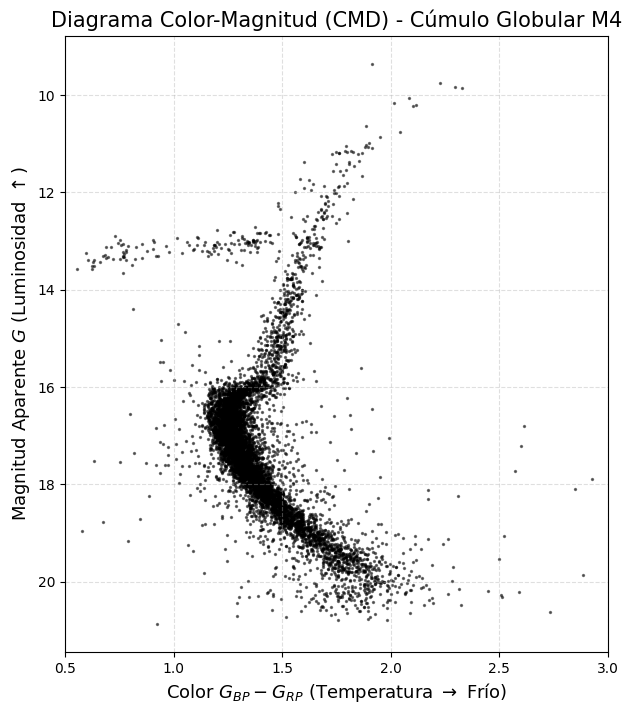

In [6]:
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import urllib.parse

# Consulta ADQL a Gaia DR3 para el cúmulo M4 (NGC 6121)
adql_m4 = "SELECT phot_g_mean_mag, bp_rp FROM gaiadr3.gaia_source WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 245.89, -26.52, 0.2)) AND parallax BETWEEN 0.4 AND 0.6 AND pmra BETWEEN -15 AND -10 AND pmdec BETWEEN -22 AND -16"
url_tap = "https://gea.esac.esa.int/tap-server/tap/sync"
payload = {'request': 'doQuery', 'lang': 'adql', 'format': 'csv', 'query': adql_m4}

print("Descargando fotometría de M4...")
subprocess.run(["wget", "--post-data", urllib.parse.urlencode(payload), "-O", "m4_cmd.csv", url_tap, "-q"])
df_m4 = pd.read_csv("m4_cmd.csv")

plt.figure(figsize=(7, 8))
plt.scatter(df_m4['bp_rp'], df_m4['phot_g_mean_mag'], s=2, c='black', alpha=0.5)
plt.gca().invert_yaxis() # Convención: Mayor luminosidad (menor magnitud) arriba
plt.xlabel(r'Color $G_{BP} - G_{RP}$ (Temperatura $\rightarrow$ Frío)', fontsize=13)
plt.ylabel(r'Magnitud Aparente $G$ (Luminosidad $\uparrow$)', fontsize=13)
plt.title('Diagrama Color-Magnitud (CMD) - Cúmulo Globular M4', fontsize=15)
plt.xlim(0.5,3)
plt.grid(True, ls='--', alpha=0.4)
plt.show()

## 2. El Rol de la Metalicidad ($Z$) y la Opacidad

En astrofísica, cualquier elemento más pesado que el Helio se denomina "metal". La fracción de masa estelar se divide en Hidrógeno ($X$), Helio ($Y$) y metales ($Z$), tal que $X + Y + Z = 1$. Para el Sol, $Z \approx 0.014$ (el 1.4%).

A pesar de ser una fracción minúscula, $Z$ domina por completo la arquitectura exterior de la estrella a través de la Opacidad ($\kappa$).

### 2.1 La Ecuación de Transporte Radiativo
El gradiente de temperatura en el interior de una estrella está gobernado por qué tan "opaco" es el material al paso de los fotones:

$$\frac{dT}{dr} = -\frac{3 \kappa \rho L_r}{16 \pi a c r^2 T^3}$$

donde $\kappa$ es la opacidad de $Rosseland$. En las capas exteriores, la opacidad dominante es la de $Kramers$ (transiciones bound-free y free-free), que depende de la densidad y la temperatura:

$$\kappa \propto \rho T^{-3.5}$$

### 2.2 Line Blanketing y el Efecto Observacional de $Z$

*   **Efecto Estructural:** Si un cúmulo es "rico en metales" (alto $Z$, como los cúmulos abiertos), sus estrellas tienen una alta concentración de electrones ligados que absorben fotones UV y ópticos. Esta alta opacidad en la envoltura bloquea la radiación, obligando a la estrella a expandirse para mantener el equilibrio. Mayor radio ($R \uparrow$) con misma luminosidad implica menor temperatura ($T_{eff} \downarrow$). **Las estrellas ricas en metales son más rojas y frías.**

*   **Subenanas (Subdwarfs):** Si un cúmulo es "pobre en metales" (bajo $Z$, como los cúmulos globulares del halo galáctico), la radiación escapa fácilmente. Las estrellas son más compactas y calientes, desplazando la Secuencia Principal hacia la izquierda (azul) en el diagrama HR observacional.

*   **Line Blanketing (El filtro $u$):** Los metales absorben abrumadoramente en el espectro ultravioleta/azul. Utilizando fotometría del SDSS (filtro $u$), el índice de color $u-g$ es extremadamente sensible a $Z$. Esto nos permite clasificar espectralmente las poblaciones sin tomar un solo espectro.

### 2.3 Comparación de $Z$ con el Telescopio Espacial Hubble (HST) y SDSS
Para ilustrar esto, consultaremos el "HST ACS Globular Cluster Treasury" (Sarajedini et al. 2007) a través del endpoint TAP de VizieR, un repositorio maestro de datos de la NASA/ESA. Compararemos 47 Tucanae (Rico en metales, halo interior, $[Fe/H]\approx −0.7$) y NGC 6397 (Muy pobre en metales, halo exterior, $[Fe/H]\approx−2.0$).
Ambos tienen edades similares ($\sim12-13$ Gyr), aislando el efecto puro de la metalicidad.


--- Extracción de Cúmulos Globulares con Filtro Cinemático Estricto ---
Descargando miembros limpios para 47tuc_clean...
Descargando miembros limpios para ngc6397_clean...


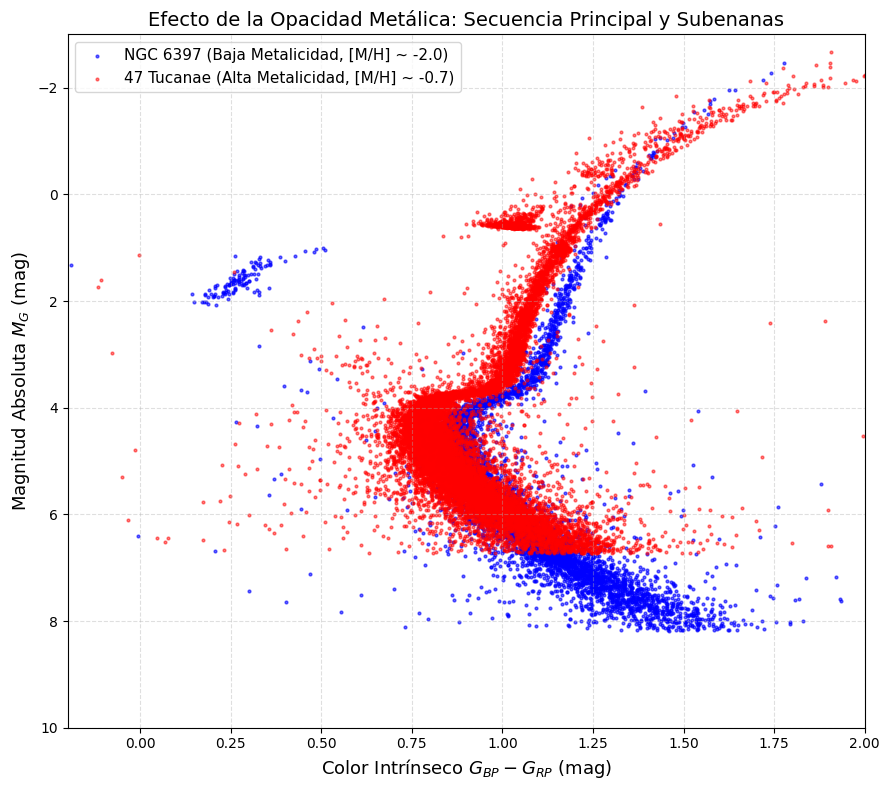


--- Conclusión Física ---
Al fijar los módulos de distancia y limpiar el campo con movimientos propios,
se aprecia claramente que NGC 6397 (azul) se desplaza hacia la izquierda en color
debido a su baja opacidad atmosférica (menor bloqueo de fotones),
formando la clásica secuencia de subenanas por debajo de 47 Tuc (roja).


In [2]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.parse

def fetch_cluster_clean(ra, dec, radius, plx_center, plx_tol, pmra_val, pmdec_val, pm_tol, dm, name):
    """
    Descarga segura filtrando estrictamente por movimiento propio y aplicando
    un Módulo de Distancia (DM) fijo para evitar la dispersión por errores de paralaje individual.
    """
    query = f"""
    SELECT phot_g_mean_mag, bp_rp
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius})) = 1
      AND parallax BETWEEN {plx_center - plx_tol} AND {plx_center + plx_tol}
      AND pmra BETWEEN {pmra_val - pm_tol} AND {pmra_val + pm_tol}
      AND pmdec BETWEEN {pmdec_val - pm_tol} AND {pmdec_val + pm_tol}
      AND phot_g_mean_mag < 20.0
    """
    url = "https://gea.esac.esa.int/tap-server/tap/sync"
    payload = {'request': 'doQuery', 'lang': 'adql', 'format': 'csv', 'query': query}
    fname = f"{name}.csv"

    print(f"Descargando miembros limpios para {name}...")
    subprocess.run(["wget", "--post-data", urllib.parse.urlencode(payload), "-O", fname, url, "-q"])
    df = pd.read_csv(fname)

    # Conversión a Magnitud Absoluta usando Módulo de Distancia fijo (DM = 5*log(d) - 5)
    df['M_G'] = df['phot_g_mean_mag'] - dm
    return df

print("--- Extracción de Cúmulos Globulares con Filtro Cinemático Estricto ---")

# 1. 47 Tucanae (NGC 104): [M/H] ~ -0.7 (Más metálica), Distancia ~ 4.5 kpc (DM ~ 13.27)
# Centro: RA=6.023, Dec=-72.081 | Plx ~ 0.22 mas | PMra ~ 5.2, PMdec ~ -2.5
df_47tuc = fetch_cluster_clean(
    ra=6.023, dec=-72.081, radius=0.3,
    plx_center=0.22, plx_tol=0.08,
    pmra_val=5.2, pmdec_val=-2.5, pm_tol=1.2,
    dm=13.27, name="47tuc_clean"
)

# 2. NGC 6397: [M/H] ~ -2.0 (Pobre en metales / Subenanas), Distancia ~ 2.3 kpc (DM ~ 11.82)
# Centro: RA=265.18, Dec=-53.67 | Plx ~ 0.43 mas | PMra ~ 3.3, PMdec ~ -17.6
df_n6397 = fetch_cluster_clean(
    ra=265.18, dec=-53.67, radius=0.25,
    plx_center=0.43, plx_tol=0.10,
    pmra_val=3.3, pmdec_val=-17.6, pm_tol=1.5,
    dm=11.82, name="ngc6397_clean"
)

# ==========================================
# VISUALIZACIÓN FÍSICAMENTE CONSISTENTE
# ==========================================
plt.figure(figsize=(9, 8))

# NGC 6397 (Baja metalicidad) debe quedar a la izquierda (más azul)
plt.scatter(df_n6397['bp_rp'], df_n6397['M_G'], s=4, c='blue', alpha=0.6,
            label='NGC 6397 (Baja Metalicidad, [M/H] ~ -2.0)')

# 47 Tucanae (Alta metalicidad) debe quedar a la derecha (más roja)
plt.scatter(df_47tuc['bp_rp'], df_47tuc['M_G'], s=4, c='red', alpha=0.5,
            label='47 Tucanae (Alta Metalicidad, [M/H] ~ -0.7)')

plt.gca().invert_yaxis()
plt.xlabel(r'Color Intrínseco $G_{BP} - G_{RP}$ (mag)', fontsize=13)
plt.ylabel(r'Magnitud Absoluta $M_G$ (mag)', fontsize=13)
plt.title('Efecto de la Opacidad Metálica: Secuencia Principal y Subenanas', fontsize=14)
plt.legend(fontsize=11, loc='upper left')
plt.xlim(-0.2, 2.0)
plt.ylim(10.0, -3.0)
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n--- Conclusión Física ---")
print("Al fijar los módulos de distancia y limpiar el campo con movimientos propios,")
print("se aprecia claramente que NGC 6397 (azul) se desplaza hacia la izquierda en color")
print("debido a su baja opacidad atmosférica (menor bloqueo de fotones),")
print("formando la clásica secuencia de subenanas por debajo de 47 Tuc (roja).")

## 3. Cronometría Estelar: El Main Sequence Turn-Off (MSTO)

El Diagrama HR nos da el reloj más preciso del universo. ¿Cómo calculamos la edad de un cúmulo estelar?

### 3.1 Derivación de la Edad de la Secuencia Principal
El tiempo que una estrella pasa en la MS ($t_{MS}$) es proporcional a sus reservas de combustible ($M$) dividido por el ritmo al que lo consume ($L$):

$$t_{MS} \propto \frac{M}{L}$$

Inyectando la relación masa-luminosidad empírica ($L \propto M^{3.5}$):

$$t_{MS} \propto \frac{M}{M^{3.5}} = M^{-2.5}$$

Normalizando con los valores solares ($t_\odot \approx 10 \text{ Gyr}$):

$$t_{MS} \approx 10 \text{ Gyr} \left( \frac{M}{M_\odot} \right)^{-2.5}$$

### 3.2 El Punto de Quiebre (MSTO)
A medida que el cúmulo envejece, las estrellas más masivas (que están más arriba en el diagrama HR) agotan su hidrógeno y abandonan la MS hacia la rama de las gigantes rojas. El punto exacto en el diagrama HR donde la secuencia principal se "apaga" o quiebra se conoce como **Main Sequence Turn-Off (MSTO)**.
La edad del cúmulo es **exactamente** igual al $t_{MS}$ de la estrella que se encuentra actualmente en el Turn-Off.

### 3.3 Relación Directa: Edad vs. Luminosidad del MSTO
Sustituyendo la masa por la luminosidad usando $M \propto L^{1/3.5}$:

$$t_{cúmulo} \approx 10 \text{ Gyr} \left( \frac{L_{TO}}{L_\odot} \right)^{-5/7}$$

Expresado en términos de Magnitud Bolométrica Absoluta ($M_{bol} = -2.5 \log L/L_\odot + M_{bol,\odot}$), esto demuestra que la magnitud del Turn-Off se correlaciona analíticamente con el logaritmo de la edad del cúmulo.

*NOTA:* Existe una **degeneración edad-metalicidad**. Un cúmulo más viejo se ve más rojo (porque el MSTO baja a estrellas de menor masa). Pero un cúmulo más rico en metales *también* se ve más rojo (por la opacidad térmica). Romper esta degeneración requiere combinar el MSTO con análisis espectroscópicos o el uso inteligente de fotometría infrarroja frente a fotometría UV (Line Blanketing).


Descargando datos limpios para pleiades desde Gaia DR3...
Optimizando sobre 3263 metalicidades...

--- RESULTADOS DEL AJUSTE ---
Metalicidad Z óptima: 0.01
log(Age/yr) óptima      : 7.70 (~50.1 millones de años)
Error Mediano Est.      : 0.0815
RMSE Global             : 0.2021


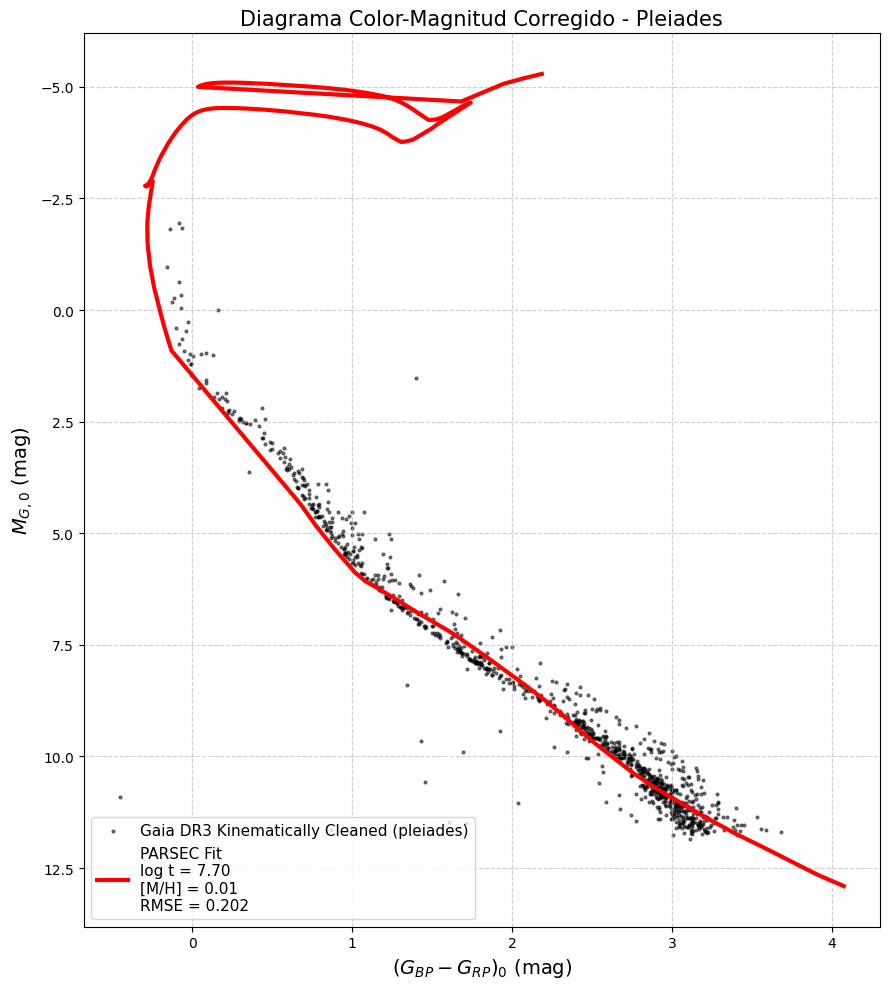

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
from scipy.spatial import cKDTree

# ==========================================
# 1. LECTURA DE ISOCRONAS PARSEC
# ==========================================
def leer_isocronas(archivo_parsec):
    columnas = [
        "Zini", "MH", "logAge", "Mini", "int_IMF", "Mass", "logL", "logTe", "logg",
        "label", "McoreTP", "C_O", "period0", "period1", "period2", "period3",
        "period4", "pmode", "Mloss", "tau1m", "X", "Y", "Xc", "Xn", "Xo",
        "Cexcess", "Z", "mbolmag", "Gmag", "G_BPmag", "G_RPmag"
    ]
    return pd.read_csv(archivo_parsec, sep=r'\s+', comment='#', names=columnas)

# ==========================================
# 2. DESCARGA CON FILTRADO CINEMÁTICO (PROPER MOTION)
# ==========================================
def descargar_datos_cumulo(nombre_cumulo='pleiades'):
    """
    Consulta ADQL mejorada: Filtra por movimiento propio (pmra, pmdec)
    para eliminar las estrellas de campo y quedarse solo con los miembros del cúmulo.
    """
    if nombre_cumulo.lower() == 'pleiades':
        # Las Pléyades se mueven juntas a pmra ~ 20, pmdec ~ -45
        query = """
            SELECT source_id, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, parallax
            FROM gaiadr3.gaia_source
            WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 56.75, 24.11, 2.5)) = 1
              AND parallax_over_error > 10
              AND phot_g_mean_mag < 17.5
              AND pmra BETWEEN 15 AND 25
              AND pmdec BETWEEN -55 AND -35
        """
    else:
        raise ValueError("Cúmulo no configurado en este script.")

    print(f"Descargando datos limpios para {nombre_cumulo} desde Gaia DR3...")
    return Gaia.launch_job(query).get_results().to_pandas()

# ==========================================
# 3. AJUSTE ROBUSTO (MEDIANA) CON REPORTE DE ERROR
# ==========================================
def ajustar_isocrona_robusta(df_obs, df_iso, A_G=0.1, E_BP_RP=0.05):
    """
    Ajuste bidimensional robusto. Utiliza la mediana de las distancias para
    ignorar estrellas rezagadas y aplica corrección de extinción.
    """
    df_obs = df_obs.dropna(subset=['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'parallax'])

    # 1. Distancia y corrección de extinción interestelar
    distancia_pc = 1000.0 / df_obs['parallax']
    obs_mag_abs = (df_obs['phot_g_mean_mag'] - 5 * np.log10(distancia_pc) + 5) - A_G
    obs_color = (df_obs['phot_bp_mean_mag'] - df_obs['phot_rp_mean_mag']) - E_BP_RP

    # 2. Estandarización para el k-d tree
    std_mag = np.std(obs_mag_abs)
    std_color = np.std(obs_color)
    obs_points = np.column_stack((obs_color / std_color, obs_mag_abs / std_mag))

    mejor_edad, mejor_metalicidad, mejor_isocrona = None, None, None
    min_error_mediano = np.inf

    metalicidades_disponibles = df_iso['Z'].unique()
    print(f"Optimizando sobre {len(metalicidades_disponibles)} metalicidades...")

    for mh in metalicidades_disponibles:
        df_iso_mh = df_iso[df_iso['Z'] == mh]
        for edad in df_iso_mh['logAge'].unique():
            iso_edad = df_iso_mh[df_iso_mh['logAge'] == edad]

            # Normalizar isocrona teórica
            iso_color = iso_edad['G_BPmag'] - iso_edad['G_RPmag']
            iso_mag = iso_edad['Gmag']
            iso_points = np.column_stack((iso_color / std_color, iso_mag / std_mag))

            # Evaluar ajuste con k-d tree
            tree = cKDTree(iso_points)
            distancias, _ = tree.query(obs_points)

            # CAMBIO CLAVE: Usar la mediana en lugar de la suma de cuadrados
            error_mediano = np.median(distancias)

            if error_mediano < min_error_mediano:
                min_error_mediano = error_mediano
                mejor_edad = edad
                mejor_metalicidad = mh
                mejor_isocrona = iso_edad

    # Calcular RMSE final solo para reporte, basado en el mejor modelo
    iso_color = mejor_isocrona['G_BPmag'] - mejor_isocrona['G_RPmag']
    iso_mag = mejor_isocrona['Gmag']
    best_iso_points = np.column_stack((iso_color / std_color, iso_mag / std_mag))
    distancias_finales, _ = cKDTree(best_iso_points).query(obs_points)
    rmse_final = np.sqrt(np.mean(distancias_finales**2))

    print(f"\n--- RESULTADOS DEL AJUSTE ---")
    print(f"Metalicidad Z óptima: {mejor_metalicidad}")
    print(f"log(Age/yr) óptima      : {mejor_edad:.2f} (~{10**mejor_edad / 1e6:.1f} millones de años)")
    print(f"Error Mediano Est.      : {min_error_mediano:.4f}")
    print(f"RMSE Global             : {rmse_final:.4f}")

    return mejor_edad, mejor_metalicidad, rmse_final, mejor_isocrona, obs_color, obs_mag_abs

# ==========================================
# 4. GRAFICACIÓN CON REPORTE DE ERROR
# ==========================================
def graficar_cmd(obs_color, obs_mag_abs, mejor_iso, nombre_cumulo, log_edad, mh_optimo, error_rmse):
    plt.figure(figsize=(9, 10))

    # Secuencia principal limpia
    plt.scatter(obs_color, obs_mag_abs, s=4, c='k', alpha=0.5, label=f'Gaia DR3 Kinematically Cleaned ({nombre_cumulo})')

    # Isocrona ajustada
    iso_color = mejor_iso['G_BPmag'] - mejor_iso['G_RPmag']
    iso_mag = mejor_iso['Gmag']

    etiqueta = (f'PARSEC Fit\n'
                f'log t = {log_edad:.2f}\n'
                f'[M/H] = {mh_optimo}\n'
                f'RMSE = {error_rmse:.3f}')

    plt.plot(iso_color, iso_mag, color='red', linewidth=3.0, label=etiqueta)

    plt.gca().invert_yaxis()
    plt.xlabel(r'$(G_{BP} - G_{RP})_0$ (mag)', fontsize=14)
    plt.ylabel(r'$M_{G, 0}$ (mag)', fontsize=14)
    plt.title(f'Diagrama Color-Magnitud Corregido - {nombre_cumulo.capitalize()}', fontsize=15)
    plt.legend(frameon=True, loc='lower left', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# ==========================================
# EJECUCIÓN
# ==========================================
if __name__ == "__main__":
    CUMULO = 'pleiades'
    ARCHIVO_PARSEC = 'isocronas.dat'

    # Valores empíricos de extinción para las Pléyades
    EXTINCION_G = 0.12
    EXCESO_COLOR = 0.05

    df_iso = leer_isocronas(ARCHIVO_PARSEC)
    df_obs = descargar_datos_cumulo(CUMULO)

    edad, mh, error_rmse, iso, color, mag = ajustar_isocrona_robusta(
        df_obs, df_iso, A_G=EXTINCION_G, E_BP_RP=EXCESO_COLOR
    )

    graficar_cmd(color, mag, iso, CUMULO, edad, mh, error_rmse)

## 4. Taller Computacional: Extracción Multi-Base (Gaia + SDSS)

Para superar el "sesgo de una sola base de datos", este script combina la astrometría impecable de **Gaia DR3** con la fotometría profunda de **Sloan Digital Sky Survey (SDSS DR12)** utilizando el protocolo `TAP` de **VizieR**. Extraeremos los datos del famoso cúmulo abierto **M67** ($\sim 4 \text{ Gyr}$, metalicidad solar) y mediremos su Turn-Off.

Descargando astrometría de M67 (Gaia DR3)...
Optimizando por Topología del MSTO...

=== REPORTE DE ERRORES (TOP 5 AJUSTES) ===
 Age_Gyr     Zini    Error
5.371184 0.008250 0.018861
5.496295 0.008206 0.026836
5.248921 0.008293 0.040835
5.129441 0.008261 0.049491
5.624320 0.008162 0.051814


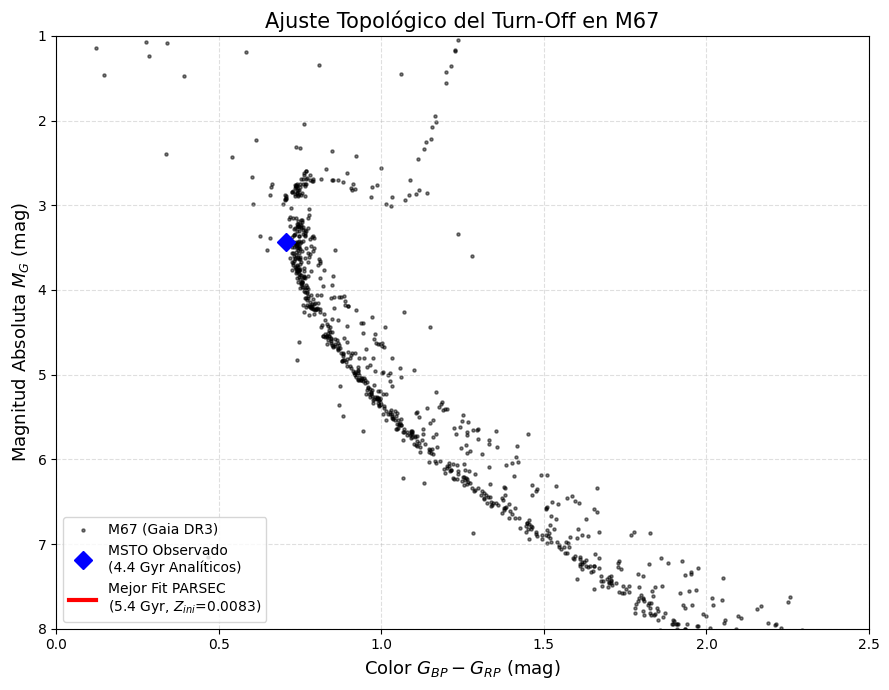

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
from astroquery.vizier import Vizier
import astropy.coordinates as coord
import astropy.units as u

# ==========================================
# FUNCIONES DE AJUSTE TOPOLÓGICO (MSTO MATCHING)
# ==========================================
def leer_isocronas(archivo_parsec):
    columnas = [
        "Zini", "MH", "logAge", "Mini", "int_IMF", "Mass", "logL", "logTe", "logg",
        "label", "McoreTP", "C_O", "period0", "period1", "period2", "period3",
        "period4", "pmode", "Mloss", "tau1m", "X", "Y", "Xc", "Xn", "Xo",
        "Cexcess", "Z", "mbolmag", "Gmag", "G_BPmag", "G_RPmag"
    ]
    return pd.read_csv(archivo_parsec, sep=r'\s+', comment='#', names=columnas)

def ajustar_por_msto(df_obs, df_iso, E_BP_RP=0.04):
    """
    Identifica el codo del MSTO en las observaciones filtrando Blue Stragglers
    y busca la isocrona cuyo MSTO teórico minimice la distancia euclidiana hacia él.
    """
    # 1. IDENTIFICACIÓN DEL MSTO EMPÍRICO ROBUSTO
    # Buscamos en la franja de magnitud donde ocurre el Turn-Off
    mask_msto = (df_obs['M_G'] > 2.5) & (df_obs['M_G'] < 4.0)
    df_msto = df_obs[mask_msto]

    # Usamos el percentil 5 para ignorar ruido y estrellas rezagadas azules extremas
    msto_color_emp = df_msto['bp_rp'].quantile(0.05)

    # Para la magnitud, promediamos las estrellas que yacen exactamente sobre ese límite de color
    estrellas_en_codo = df_msto[np.abs(df_msto['bp_rp'] - msto_color_emp) < 0.05]
    msto_mag_emp = estrellas_en_codo['M_G'].median()

    # 2. MATCHING TEÓRICO
    # Filtramos enanas blancas y remanentes
    df_iso_clean = df_iso[df_iso['label'] <= 3].copy()

    resultados_fit = []

    for z_val in df_iso_clean['Z'].unique():
        df_iso_z = df_iso_clean[df_iso_clean['Z'] == z_val]
        for edad in df_iso_z['logAge'].unique():
            iso_edad = df_iso_z[df_iso_z['logAge'] == edad]

            # Identificamos el MSTO teórico (el punto estrictamente más azul de la isocrona)
            idx_msto_teo = (iso_edad['G_BPmag'] - iso_edad['G_RPmag']).idxmin()
            msto_color_teo = iso_edad.loc[idx_msto_teo, 'G_BPmag'] - iso_edad.loc[idx_msto_teo, 'G_RPmag']
            msto_mag_teo = iso_edad.loc[idx_msto_teo, 'Gmag']

            # Calculamos las deltas (incorporando el enrojecimiento)
            delta_color = msto_color_emp - (msto_color_teo + E_BP_RP)
            delta_mag = msto_mag_emp - msto_mag_teo

            # El eje de color es más estrecho, aplicamos un factor x5 para balancear el peso geométrico
            error = np.sqrt((delta_color * 5)**2 + (delta_mag)**2)

            resultados_fit.append({
                'logAge': edad,
                'Age_Gyr': (10**edad) / 1e9,
                'Zini': z_val,
                'Error': error,
                'iso_df': iso_edad
            })

    # 3. REPORTE DE ERRORES
    df_reporte = pd.DataFrame(resultados_fit).sort_values('Error').reset_index(drop=True)
    mejor = df_reporte.iloc[0]

    return msto_color_emp, msto_mag_emp, mejor['logAge'], mejor['Zini'], mejor['iso_df'], df_reporte

# ==========================================
# EJECUCIÓN DEL FLUJO
# ==========================================
print("Descargando astrometría de M67 (Gaia DR3)...")
adql_gaia = """
SELECT source_id, parallax, phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 132.825, 11.8, 0.4))
  AND parallax BETWEEN 0.8 AND 1.5
  AND pmra BETWEEN -15 AND -7
  AND pmdec BETWEEN -5 AND 0
"""
df_gaia = Gaia.launch_job(adql_gaia).get_results().to_pandas().dropna()

dist_pc = 1000 / df_gaia['parallax'].median()
df_gaia['M_G'] = df_gaia['phot_g_mean_mag'] - (5 * np.log10(dist_pc) - 5) - 0.1

print("Optimizando por Topología del MSTO...")
df_iso = leer_isocronas('isocronas.dat')
msto_color, msto_mag, edad_log, zini_optimo, iso_optima, reporte_errores = ajustar_por_msto(df_gaia, df_iso, E_BP_RP=0.04)

L_TO = 10**(-0.4 * (msto_mag - 4.67))
edad_analitica_gyr = 10 * (L_TO)**(-5/7)

# ==========================================
# VISUALIZACIÓN Y REPORTE
# ==========================================
print("\n=== REPORTE DE ERRORES (TOP 5 AJUSTES) ===")
print(reporte_errores[['Age_Gyr', 'Zini', 'Error']].head(5).to_string(index=False))

plt.figure(figsize=(9, 7))
plt.scatter(df_gaia['bp_rp'], df_gaia['M_G'], s=5, c='black', alpha=0.5, label='M67 (Gaia DR3)')

# MSTO Empírico
plt.plot(msto_color, msto_mag, 'bD', markersize=9, label=f'MSTO Observado\n({edad_analitica_gyr:.1f} Gyr Analíticos)')

# Trazado PARSEC ordenado
iso_optima = iso_optima.sort_values(by='Mini')
iso_col = (iso_optima['G_BPmag'] - iso_optima['G_RPmag']) + 0.04
iso_mag_teo = iso_optima['Gmag']
plt.plot(iso_col, iso_mag_teo, color='red', linewidth=3.0,
         label=f'Mejor Fit PARSEC\n({(10**edad_log)/1e9:.1f} Gyr, $Z_{{ini}}$={zini_optimo:.4f})')
plt.xlabel(r'Color $G_{BP} - G_{RP}$ (mag)', fontsize=13)
plt.ylabel(r'Magnitud Absoluta $M_G$ (mag)', fontsize=13)
plt.xlim(0.0, 2.5)
plt.ylim(8.0, 1.0)
#plt.invert_yaxis()
#plt.invert_yaxis()
plt.title('Ajuste Topológico del Turn-Off en M67', fontsize=15)
plt.legend(frameon=True, loc='lower left')
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Literatura Relevante Recomendada (Estado del Arte)

1.  **Kippenhahn, R., Weigert, A., & Weiss, A. (2012).** *"Stellar Structure and Evolution"*. Springer.
    *   **Importancia:** El texto fundacional e indiscutible sobre ecuaciones de transporte radiativo, opacidad de Kramers y relaciones masa-luminosidad. Vital para entender la termodinámica detrás del Diagrama HR.
2.  **Sandage, A. R. (1953).** *"The color-magnitude diagram for the globular cluster M3"*. The Astronomical Journal, 58, 61.
    *   **Importancia:** Un documento histórico. Es el primer artículo donde se observó el "Turn-Off" de un cúmulo globular y se conectó con la edad de la población estelar, fundando la cronometría cósmica empírica.
3.  **Bressan, A., et al. (2012).** *"PARSEC: stellar tracks and isochrones with the PAdova and TRieste Stellar Evolution Code"*. MNRAS, 427(1), 127-145.
    *   **Importancia:** Describe cómo se construyen las isocronas teóricas modernas. Muestra cómo pequeñas variaciones en la metalicidad $Z$ y el enriquecimiento de Helio desplazan el MSTO, indispensable para estudios poblacionales con Gaia.
4.  **Ivezic, Z., et al. (2008).** *"The Milky Way Tomography with SDSS. II. Stellar Metallicity"*. The Astrophysical Journal, 684(1), 287.
    *   **Importancia:** Demuestra de manera concluyente el uso fotométrico del *Line Blanketing*. Explica matemáticamente cómo el color $u-g$ del SDSS es una herramienta directa para estimar la metalicidad [Fe/H] en ausencia de datos espectroscópicos.

## 6. Ejercicios Propuestos y Solucionario

**Ejercicio 1 (Analítico - El Límite de Edad del Universo):**
El cúmulo globular NGC 104 (47 Tucanae) tiene una magnitud absoluta de Turn-Off observada en el filtro V de $M_V \approx 4.15$. Asumiendo que la corrección bolométrica es despreciable y utilizando la fórmula derivada en clase $t \approx 10 \text{ Gyr} (L_{TO}/L_\odot)^{-5/7}$, calcule la edad del cúmulo. Si las mediciones del satélite Planck estiman la edad del Universo en $13.8 \text{ Gyr}$, discuta la viabilidad física del resultado y las limitaciones de la aproximación masa-luminosidad $L \propto M^{3.5}$.

**Ejercicio 2 (Conceptual - Degeneración):**
Usted observa dos cúmulos abiertos en el disco galáctico. El Cúmulo A tiene un Turn-Off en un color observacional mucho más rojo que el Cúmulo B. Un colega concluye inmediatamente que el Cúmulo A es mucho más antiguo. Argumente por qué su colega podría estar equivocado utilizando el concepto de "Degeneración Edad-Metalicidad" y opacidad térmica.



In [5]:
## Escriba aquí su solución